FIXED RANDOM FOREST MODEL - BINARY CLASSIFICATION

[STEP 1] Loading dataset...
Dataset shape: (1000, 7)

[STEP 2] Converting to numeric...

[STEP 3] CRITICAL FIX - Creating binary labels...
Original labels (first 10):
['Needs Water + Too Low Nutrients in Water', 'Needs Water + Too Hot + Poor Water Quality', 'Soil Too Acidic', 'Needs Water + Too Hot', 'Needs Water + Too Hot + Poor Water Quality + High Humidity', 'Healthy', 'Poor Water Quality + Low Humidity', 'Too Hot', 'Too Low Nutrients in Water', 'Healthy']

Binary label distribution:
  Class 0 (Healthy): 120
  Class 1 (Unhealthy): 880

[STEP 4] Preparing features and target...
Feature matrix shape: (1000, 5)
Target distribution:
  Healthy (0): 120 (12.0%)
  Unhealthy (1): 880 (88.0%)

[STEP 5] Splitting data (80-20)...
Training set: 800 samples
Test set: 200 samples

[STEP 6] Training Random Forest...
Training complete!
EVALUATION METRICS

Training Accuracy: 100.00%

Test Accuracy:  99.50%
Precision:      99.44%
Recall:         100.

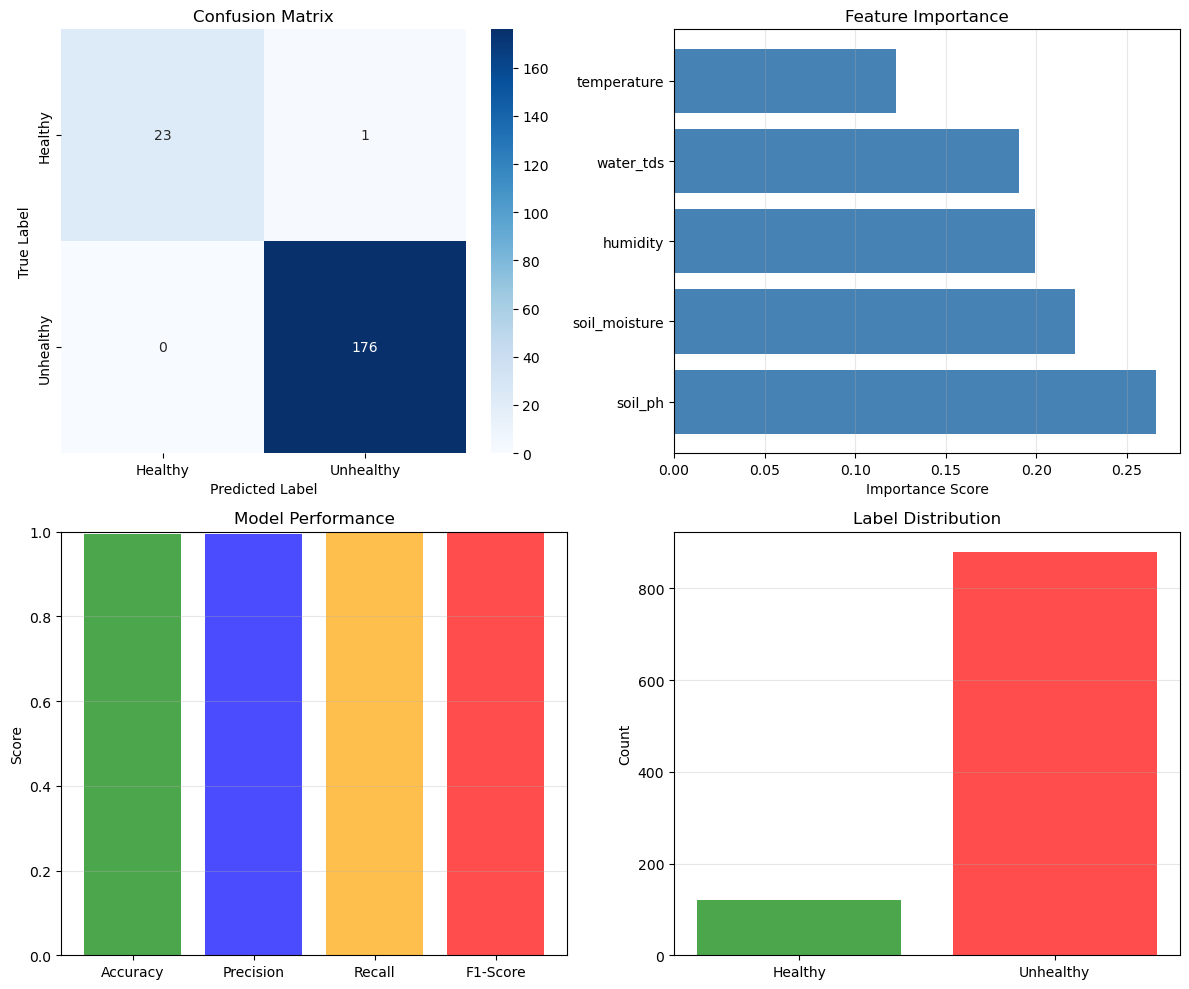


[STEP 8] Saving model...
Saved: plant_health_model_binary.joblib

[STEP 9] Testing model reload...
Model loaded successfully!

Test prediction:
  Input: [ 36.7927136   34.23680052   6.7639488  310.06583531  71.99202831]
  Prediction: 1 (Unhealthy)
  Confidence: 100.00%
MODEL TRAINING COMPLETE!

Summary:
  Binary Classes: Healthy (0) vs Unhealthy (1)
  Test Accuracy: 99.50%
  Recall: 100.00%
  Top Feature: soil_ph (26.61%)
  Model file: plant_health_model_binary.joblib


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

print("FIXED RANDOM FOREST MODEL - BINARY CLASSIFICATION")

# STEP 1: Load Dataset
print("\n[STEP 1] Loading dataset...")
file_path = r"C:\Users\agraw\OneDrive - Manipal University Jaipur\Documents\synthetic_plant_data.xlsx"

raw_df = pd.read_excel(file_path, header=None)
df = raw_df[0].str.split(",", expand=True)
df.columns = df.iloc[0]
df = df[1:]

print(f"Dataset shape: {df.shape}")

# STEP 2: Convert to numeric
print("\n[STEP 2] Converting to numeric...")
numeric_cols = ['temperature', 'soil_moisture', 'soil_ph', 'water_tds', 'humidity']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# STEP 3: FIX - BINARY CLASSIFICATION
print("\n[STEP 3] CRITICAL FIX - Creating binary labels...")
print("Original labels (first 10):")
print(df['label'].head(10).tolist())

df['label_binary'] = df['label'].apply(lambda x: 0 if 'Healthy' in str(x) else 1)

print("\nBinary label distribution:")
print(f"  Class 0 (Healthy): {(df['label_binary'] == 0).sum()}")
print(f"  Class 1 (Unhealthy): {(df['label_binary'] == 1).sum()}")

# Remove NaN
df = df.dropna(subset=numeric_cols + ['label_binary'])

# STEP 4: Prepare data
print("\n[STEP 4] Preparing features and target...")
X = df[numeric_cols].copy()
y = df['label_binary'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:")
print(f"  Healthy (0): {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.1f}%)")
print(f"  Unhealthy (1): {(y == 1).sum()} ({(y == 1).sum()/len(y)*100:.1f}%)")

# STEP 5: Train-Test Split
print("\n[STEP 5] Splitting data (80-20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# STEP 6: Train Model
print("\n[STEP 6] Training Random Forest...")
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Training complete!")

# STEP 7: Evaluate
print("EVALUATION METRICS")

# Training accuracy
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"\nTraining Accuracy: {train_acc*100:.2f}%")

# Test metrics
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nTest Accuracy:  {test_acc*100:.2f}%")
print(f"Precision:      {precision*100:.2f}%")
print(f"Recall:         {recall*100:.2f}%")
print(f"F1-Score:       {f1*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn} | False Positives: {fp}")
print(f"  False Negatives: {fn} | True Positives:  {tp}")
print(f"\nSensitivity (catches stressed plants): {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")

# STEP 8: Feature Importance
print("FEATURE IMPORTANCE")

feature_importance = pd.DataFrame({
    'Feature': numeric_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRanking:")
for idx, row in feature_importance.iterrows():
    print(f"  {row['Feature']:15s}: {row['Importance']*100:5.2f}%")

# STEP 9: Visualization
print("\n[STEP 7] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Healthy', 'Unhealthy'],
            yticklabels=['Healthy', 'Unhealthy'])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# Feature Importance
axes[0, 1].barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
axes[0, 1].set_xlabel('Importance Score')
axes[0, 1].set_title('Feature Importance')
axes[0, 1].grid(axis='x', alpha=0.3)

# Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [test_acc, precision, recall, f1]
axes[1, 0].bar(metrics, values, color=['green', 'blue', 'orange', 'red'], alpha=0.7)
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Model Performance')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)

# Label Distribution
label_dist = y.value_counts()
axes[1, 1].bar(['Healthy', 'Unhealthy'], [label_dist[0], label_dist[1]], 
               color=['green', 'red'], alpha=0.7)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Label Distribution')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
print("Saved: model_performance.png")
plt.show()

# STEP 10: Save Model
print("\n[STEP 8] Saving model...")
joblib.dump(model, 'plant_health_model_binary.joblib')
print("Saved: plant_health_model_binary.joblib")

# STEP 11: Test reload
print("\n[STEP 9] Testing model reload...")
loaded_model = joblib.load('plant_health_model_binary.joblib')
test_sample = X_test.iloc[0:1]
test_pred = loaded_model.predict(test_sample)[0]
test_proba = loaded_model.predict_proba(test_sample)[0]
confidence = max(test_proba) * 100

print(f"Model loaded successfully!")
print(f"\nTest prediction:")
print(f"  Input: {test_sample.values[0]}")
print(f"  Prediction: {test_pred} ({'Healthy' if test_pred == 0 else 'Unhealthy'})")
print(f"  Confidence: {confidence:.2f}%")

print("MODEL TRAINING COMPLETE!")
print(f"\nSummary:")
print(f"  Binary Classes: Healthy (0) vs Unhealthy (1)")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Recall: {recall*100:.2f}%")
print(f"  Top Feature: {feature_importance.iloc[0]['Feature']} ({feature_importance.iloc[0]['Importance']*100:.2f}%)")
print(f"  Model file: plant_health_model_binary.joblib")
